# ✅ Solutions — Session 2: Plot Types & Choosing the Right Chart

Worked solutions to all five exercises and the mini project.
Run each cell top to bottom.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Exercise 1 (Easy) — Scatter of `y = 3x + noise`

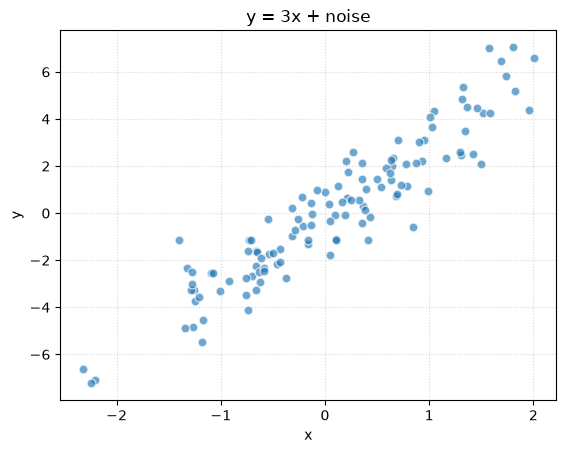

In [2]:
rng = np.random.default_rng(0)
x = rng.normal(size=120)
y = 3 * x + rng.normal(scale=1.0, size=120)

fig, ax = plt.subplots()
ax.scatter(x, y, s=40, c="tab:blue", alpha=0.65, edgecolors="white")
ax.set_title("y = 3x + noise")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, linestyle=":", alpha=0.5)
plt.show()

## Exercise 2 (Easy) — Vertical and horizontal bar charts

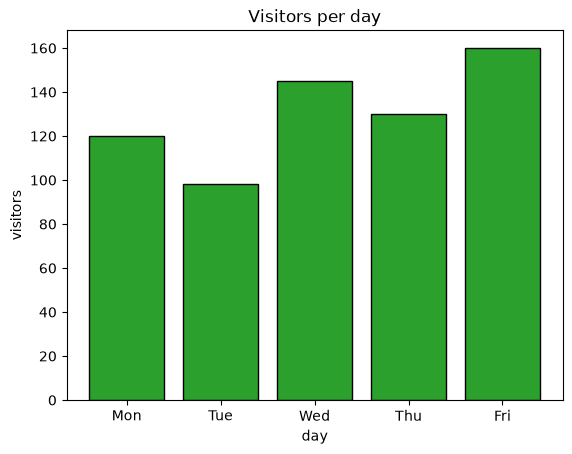

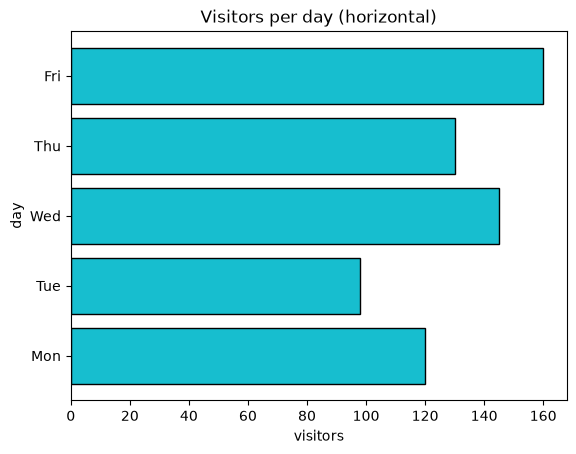

In [3]:
categories = ["Mon", "Tue", "Wed", "Thu", "Fri"]
visitors = [120, 98, 145, 130, 160]

fig, ax = plt.subplots()
ax.bar(categories, visitors, color="tab:green", edgecolor="black")
ax.set_title("Visitors per day")
ax.set_xlabel("day")
ax.set_ylabel("visitors")
plt.show()

fig, ax = plt.subplots()
ax.barh(categories, visitors, color="tab:cyan", edgecolor="black")
ax.set_title("Visitors per day (horizontal)")
ax.set_xlabel("visitors")
ax.set_ylabel("day")
plt.show()

## Exercise 3 (Medium) — Histogram and box plot of two groups

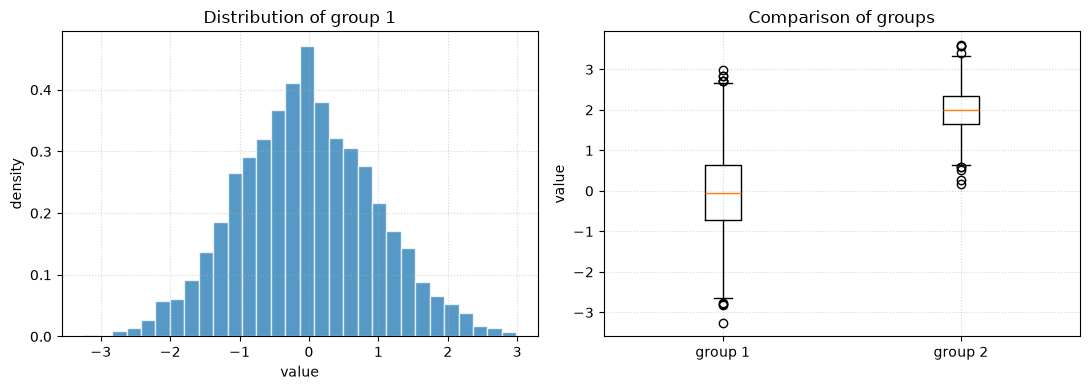

In [4]:
rng = np.random.default_rng(7)
group1 = rng.normal(loc=0, scale=1.0, size=2000)
group2 = rng.normal(loc=2, scale=0.5, size=2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(group1, bins=30, density=True, color="tab:blue", alpha=0.75,
             edgecolor="white")
axes[0].set_title("Distribution of group 1")
axes[0].set_xlabel("value")
axes[0].set_ylabel("density")
axes[0].grid(True, linestyle=":", alpha=0.5)

axes[1].boxplot([group1, group2], tick_labels=["group 1", "group 2"])
axes[1].set_title("Comparison of groups")
axes[1].set_ylabel("value")
axes[1].grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

## Exercise 4 (Medium) — Conceptual: chart choice

- **(a) Budget share across four departments → pie chart.** There are few
  categories that sum to a meaningful whole, which is exactly what a pie
  encodes well.
- **(b) Study hours vs. exam score → scatter plot.** Both variables are
  continuous and we want to see whether they move together.
- **(c) Spread of delivery times for three couriers → box plot.** It compares
  the median and spread of a numeric variable across a few categories,
  including outliers.
- **(d) Temperature reading with ±0.5 °C error → error bar plot.** Error bars
  are the standard way to show a measurement plus its uncertainty.

## Exercise 5 (Advanced) — Growing uncertainty with `errorbar` + `fill_between`

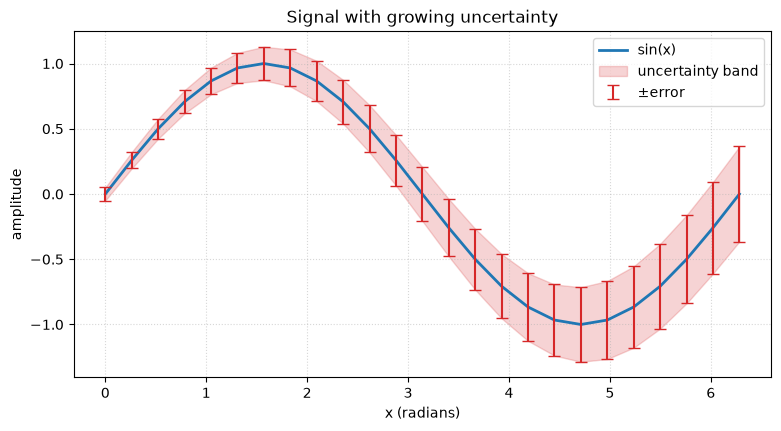

In [5]:
x = np.linspace(0, 2 * np.pi, 25)
y = np.sin(x)
err = 0.05 * (x + 1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, y, color="tab:blue", linewidth=2, label="sin(x)")
ax.errorbar(x, y, yerr=err, fmt="none", capsize=4, ecolor="tab:red",
            label="±error")
ax.fill_between(x, y - err, y + err, color="tab:red", alpha=0.2,
                label="uncertainty band")

ax.set_title("Signal with growing uncertainty")
ax.set_xlabel("x (radians)")
ax.set_ylabel("amplitude")
ax.legend(loc="upper right")
ax.grid(True, linestyle=":", alpha=0.5)
plt.show()

## 🚀 Mini Project — Distribution & Comparison

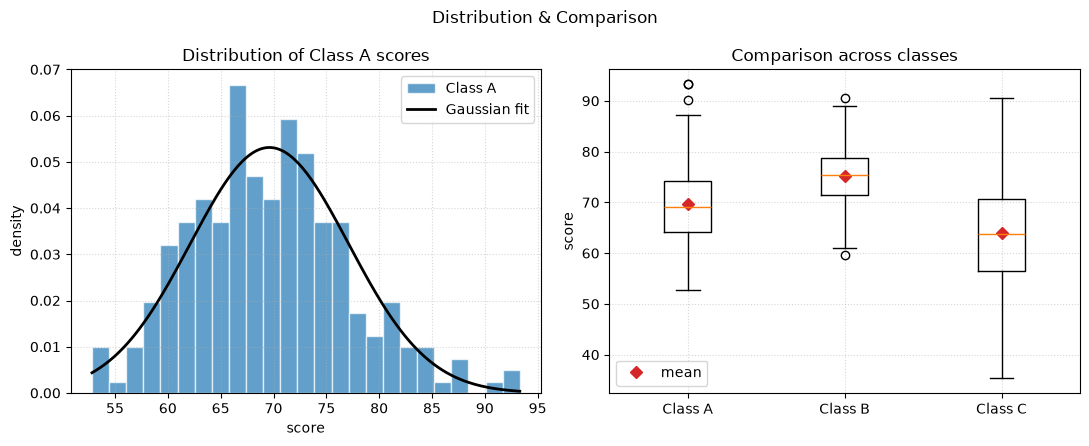

In [6]:
rng = np.random.default_rng(42)
group_a = rng.normal(loc=70, scale=8, size=250)
group_b = rng.normal(loc=75, scale=6, size=250)
group_c = rng.normal(loc=65, scale=10, size=250)
groups = [group_a, group_b, group_c]
names = ["Class A", "Class B", "Class C"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: distribution of one group with a Gaussian reference curve
ax = axes[0]
ax.hist(group_a, bins=25, density=True, color="tab:blue", alpha=0.7,
        edgecolor="white", label="Class A")
xs = np.linspace(group_a.min(), group_a.max(), 200)
pdf = np.exp(-0.5 * ((xs - group_a.mean()) / group_a.std()) ** 2) / (
    group_a.std() * np.sqrt(2 * np.pi)
)
ax.plot(xs, pdf, color="black", linewidth=2, label="Gaussian fit")
ax.set_title("Distribution of Class A scores")
ax.set_xlabel("score")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

# Right: comparison across groups with group means overlaid
ax = axes[1]
ax.boxplot(groups, tick_labels=names)
means = [g.mean() for g in groups]
ax.plot(range(1, len(groups) + 1), means, "D", color="tab:red", label="mean")
ax.set_title("Comparison across classes")
ax.set_ylabel("score")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Distribution & Comparison")
fig.tight_layout()
fig.savefig("distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()